# Logistic Regression and Classification

## 1. Introduction

Logistic Regression is a statistical model commonly used for **binary classification** problems, where the goal is to predict one of two possible outcomes. It models the probability that a given input $x$ belongs to a particular class, using a linear combination of the input features and applying a **logistic (sigmoid)** function to map the result into a probability range \([0, 1]\).

<div style="display: flex; justify-content: space-around;">
    <div style="margin-right: 10px;">
        <img src="./figures/logRe.png" alt="Figure 1" width="300" height="250">
        <p style="text-align: center;">Figure 1</p>
    </div>
    <div>
        <img src="./figures/logRe2.png" alt="Figure 2" width="300" height="250">
        <p style="text-align: center;">Figure 2</p>
    </div>
</div>

This is just like the linear regression problem, except that the values $y$ we now want to predict take on only a small number of discrete values. For now, we will focus on the binary
classication problem in which $y$ can take on only two values, 0 and 1.
(Most of what we say here will also generalize to the multiple-class case.)
For instance, if we are trying to build a spam classifier for email, then $x^i$
may be some features of a piece of email, and y may be 1 if it is a piece
of spam mail, and 0 otherwise. 0 is also called the **negative class**, and 1
the **positive class**, and they are sometimes also denoted by the symbols $-$
and $+$. Given $x^i$, the corresponding $y^i$ is also called the **label** for the
training example.


Logistic regression can also be generalized to multi-class classification problems through extensions like **multinomial logistic regression** or **softmax regression**.

## 2. The Logistic Function (Sigmoid Function)

The key component of logistic regression is the **logistic**, or **sigmoid** function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Where:
- $z = \theta^T x =\theta_0+\theta_1x_1+...+\theta_dx_d$ is the linear combination of the input features $x$ and the model parameters $\theta$.
- $\sigma(z)$ maps any real-valued number to the range $(0, 1)$, making it useful for predicting probabilities.
- $\sigma(z)$ tends towards 1 as $z\rightarrow \infty$, $\sigma(z)$ tends towards 0 as $z\rightarrow -\infty$

<img src="./figures/sigma.png" alt="Alt text" width="400" height="300" style="display: block; margin-left: auto; margin-right: auto;">

## 3. Derivative of the sigmoid function
\begin{align}
\sigma'(z)&=\frac{d}{dz}\frac{1}{1+e^{-z}}\\
&=\frac{1}{(1+e^{-z})^2}e^{-z}\\
&=\frac{1}{(1+e^{-z}}\cdot(1-\frac{1}{(1+e^{-z})})\\
&=\sigma(z)(1-\sigma(z))
\end{align}

## 4. Maximum Likelihood Estimation (MLE) of logistic regression
In logistic regression, the goal is to model the probability that a given input $x$ belongs to a particular class $y \in \{0, 1\}$. The logistic function (sigmoid) is used to map the linear combination of the input features to a probability between 0 and 1.

$$
P(y = 1 | x; \theta) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
$$

Conversely, the probability that the output is in class 0 is:

$$
P(y = 0 | x; \theta) = 1 - \sigma(\theta^T x) = \frac{e^{-\theta^T x}}{1 + e^{-\theta^T x}}
$$

For binary classification, the probability of $y$ given $ x$ parametrized by $\theta$ is:

$$
P(y | x; \theta) = \sigma(\theta^T x)^y \cdot (1 - \sigma(\theta^T x))^{1 - y}
$$

The **likelihood function** represents the probability of the observed data given the input $x$ parameterized by $\theta$. For a dataset with $n$ independent training samples $ (x^{(i)}, y^{(i)})$, the likelihood function is:

\begin{align}
L(\theta) &= p(\vec{y}\mid X;\theta)\\
& =\prod_{i=1}^{n} P(y^{(i)} | x^{(i)}; \theta)\\
&=\prod_{i=1}^{n} \sigma(\theta^T x^{(i)})^{y^{(i)}} \cdot (1 - \sigma(\theta^T x^{(i)}))^{1 - y^{(i)}}
\end{align}

Since the product of many probabilities can be numerically unstable (leading to underflow), it is common to maximize the **log-likelihood** instead. The log-likelihood loss function is given by:

$$
\ell(\theta) = \log L(\theta) = \sum_{i=1}^{n} \left[ y^{(i)} \log(\sigma(\theta^T x^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(\theta^T x^{(i)})) \right]
$$

Where:
- In logistic regression, we use the log-likelihood loss function, also called **cross-entropy loss** as the cost function, which measures how well the model's predictions match the true binary labels.
- $\sigma(\theta^T x^{(i)})$ is the predicted probability for the $i$-th sample,
- $y^{(i)} $ is the true label of the $i$-th sample.
- The log-likelihood is a concave function, so it has a unique maximum.

### How do we maximize the Log-Likelihood? 

Since there is no closed-form solution to this equation, we use **gradient descent** to iteratively update the parameters \( \theta \). The update rule is given by: $\theta_j := \theta_j + \alpha \frac{\partial \ell(\theta)}{\partial \theta_j}$, where$\alpha$ is the learning rate, controlling the step size of each update.

To find the parameters $\theta$ that maximize the log-likelihood, we take the gradient of $\ell(\theta)$ with respect to $\theta$ and set it equal to zero. The gradient of the log-likelihood for **one training data $(x, y)$** is:
\begin{align}
\frac{\partial \ell(\theta)}{\partial \theta_j} &= (y\frac{1}{\sigma(\theta^Tx)}-(1-y)\frac{1}{1-\sigma(\theta^Tx)})\frac{\partial\sigma(\theta^Tx)}{\partial\theta_j}\\
&=(y\frac{1}{\sigma(\theta^Tx)}-(1-y)\frac{1}{1-\sigma(\theta^Tx)})\sigma(\theta^Tx)(1-\sigma(\theta^Tx))\frac{\partial \theta^Tx}{\partial\theta_j}\\
&=(y(1-\sigma(\theta^Tx)) - (1-y)\sigma(\theta^Tx))x_j\\
&=(y-\sigma(\theta^Tx))x_j
\end{align}

- we used the fact that $\sigma'(z)=\sigma(z)(1-\sigma(z))$, $\frac{\partial \sigma(z)}{\partial \theta_j}=\sigma'(z)\frac{\partial z}{\partial\theta_j}$, where $z=\theta^Tx$.

Similary we can find for **$n$ training dataset**, the gradient of log-likelihood function is given by:
$$
\frac{\partial \ell(\theta)}{\partial \theta_j} = \sum_{i=1}^{n} \left( y^{(i)} - \sigma(\theta^T x^{(i)}) \right) x_j^{(i)}
$$

This represents the difference between the true label $y^{(i)}$ and the predicted probability $\sigma(\theta^T x^{(i)})$, multiplied by the corresponding input feature $x_j^{(i)}$. In matrix form, the gradient can be written as: 
$$\nabla\ell(\theta) = X^T (\vec{y} - \sigma(X \theta))$$
The **batch gradient descent (size $n$) update** can be written as:
\begin{align}
\theta := \theta + \alpha \nabla\ell(\theta)
&=\theta + \alpha X^T (\vec{y} - \sigma(X \theta))     
\end{align}
Where:
- $X \in \mathbb{R}^{n \times d}$ is the design matrix containing the input features. $d$ features and $n$ data samples.
- $y \in \mathbb{R}^{d}$ is the vector of true labels.
- $\sigma(X \theta) \in \mathbb{R}^{d}$ is the vector of predicted probabilities for all samples.

### What about the Stochastic Gradient Descent update?
For $i=1,..,n$
$$\theta_j:= \theta_j + \alpha \left( y^{(i)} - \sigma(\theta^T x^{(i)}) \right) x_j^{(i)}$$
- The gradient of the log-likelihood measures how the log-likelihood changes with respect to the parameters $\theta$.
- The update rule adjusts $\theta$ in the direction that maximizes the likelihood, moving towards the optimal parameters.
- Gradient descent continues to update $\theta$ until convergence, i.e., until the changes in $\theta$ become sufficiently small.

## 5. Regularization

To prevent overfitting, we can add regularization terms to the cost function. Two common regularization techniques used in logistic regression are **L2 regularization** (Ridge regression) and **L1 regularization** (Lasso regression).

### L2 Regularization (Ridge)

The regularized cost function is:

$$
L(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \left( y^{(i)} \log(\sigma(\theta^T x^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(\theta^T x^{(i)})) \right) + \frac{\lambda}{2n} \sum_{j=1}^{n} \theta_j^2
$$

Where $\lambda$ is the regularization parameter.

### L1 Regularization (Lasso)

The regularized cost function is:

$$
L(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \left( y^{(i)} \log(\sigma(\theta^T x^{(i)})) + (1 - y^{(i)}) \log(1 - \sigma(\theta^T x^{(i)})) \right) + \frac{\lambda}{n} \sum_{j=1}^{n} |\theta_j|
$$

## 6. Decision Boundary

Logistic regression makes a prediction by determining whether the output probability is greater than or less than 0.5. The **decision boundary** is the point where the model predicts $y = 0$ or $y = 1$. The decision rule can be expressed as:

$$
y = 
\begin{cases}
1, & \text{if } \sigma(\theta^T x) \geq 0.5 \\
0, & \text{otherwise}
\end{cases}
$$

Equivalently, the decision boundary is determined by the equation:

$$
\theta^T x = \theta_0+\theta_1x_1+...\theta_dx_d=0
$$
- It separates the feature space into two halves, one corresponding to class 1 and the other corresponding to class 0.
- It produces a linear decision boundary in the feature space.
- In logistic regression, the decision boundary is inherently **linear** with respect to the features used in the model.
- This is because logistic regression assumes a **linear relationship** between the input features and the log-odds of the target variable. 


### 7. Multiclass Logistic Regression

For multiclass classification, logistic regression can be extended using the **softmax function** (also called multinomial logistic regression). The softmax function generalizes logistic regression to more than two classes by computing a probability for each class. For $K$ classes, the probability of class $k$ is:

$$
P(y = k | x, \theta) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}
$$

The corresponding loss function for multiclass classification is the **cross-entropy loss**:

$$
J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log(P(y = k | x^{(i)}, \theta))
$$

## 8. Conclusion

Logistic regression uses maximum likelihood estimation (MLE) to estimate the model parameters. Since the likelihood function is non-linear, there is no closed-form solution, and we rely on gradient-based optimization methods like gradient descent to find the optimal parameters. By maximizing the likelihood function, we obtain the parameters that best fit the data. 

Logistic regression is a simple yet powerful technique for binary classification. It models the relationship between input features and class probabilities using the logistic function. By using gradient descent to minimize the log-loss function, we can find the optimal parameters that best fit the data. Regularization can be used to improve generalization performance and avoid overfitting.

Logistic regression can also be extended to handle multiclass classification using softmax regression.


/var/folders/8_/lr3by9ln7y5gn8t6jb2kgh7r0000gp/T/ipykernel_98351/4173904210.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


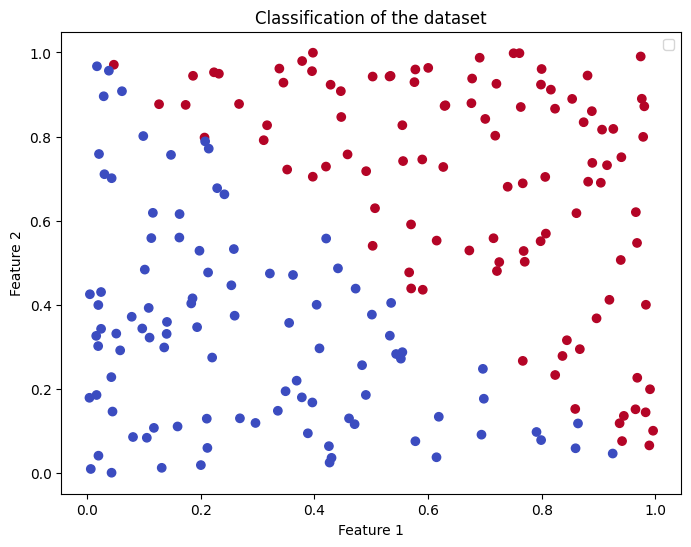

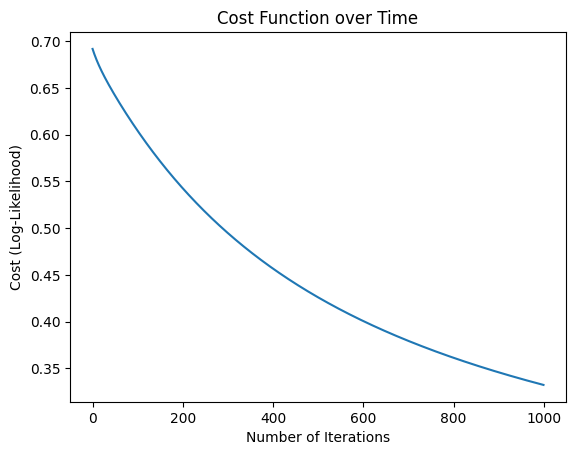

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cost function (Log-Likelihood)
def compute_cost(X, y, theta):
    n = len(y) #number of data points
    h = sigmoid(X @ theta)
    epsilon = 1e-5  # Adding small epsilon to avoid log(0)
    cost = -(1/n) * (y.T @ np.log(h + epsilon) + (1 - y).T @ np.log(1 - h + epsilon))
    return cost

# Gradient of the cost function
def gradient_descent(X, y, theta, learning_rate, num_iterations):
    n = len(y)
    cost_history = np.zeros(num_iterations)
    
    for i in range(num_iterations):
        h = sigmoid(X @ theta)
        theta -= (learning_rate/n) * (X.T @ (h - y))  # Update theta
        cost_history[i] = compute_cost(X, y, theta)   # Save cost for each iteration
    
    return theta, cost_history

# Generate synthetic binary classification data
np.random.seed(0)
num_samples = 1000
X = np.random.rand(num_samples, 2)  # Randomly generate 2 features
y = (X[:, 0] + X[:, 1] > 1).astype(int)  # Label 1 if sum of features > 1, else 0

# Add intercept term (column of ones)
X = np.c_[np.ones((X.shape[0], 1)), X]

# Visualize dataset
plt.figure(figsize=(8,6))
plt.scatter(X_test[:, 1], X_test[:, 2], c=y_test, cmap='coolwarm')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Classification of the dataset')
plt.show()


# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize parameters
theta = np.zeros(X_train.shape[1])  #zero initialization: set initial values of \theta to 0
learning_rate = 0.1
num_iterations = 1000

# Perform gradient descent
theta, cost_history = gradient_descent(X_train, y_train, theta, learning_rate, num_iterations)

# Plot cost history
plt.plot(cost_history)
plt.title("Cost Function over Time")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (Log-Likelihood)")
plt.show()

Accuracy: 97.00%


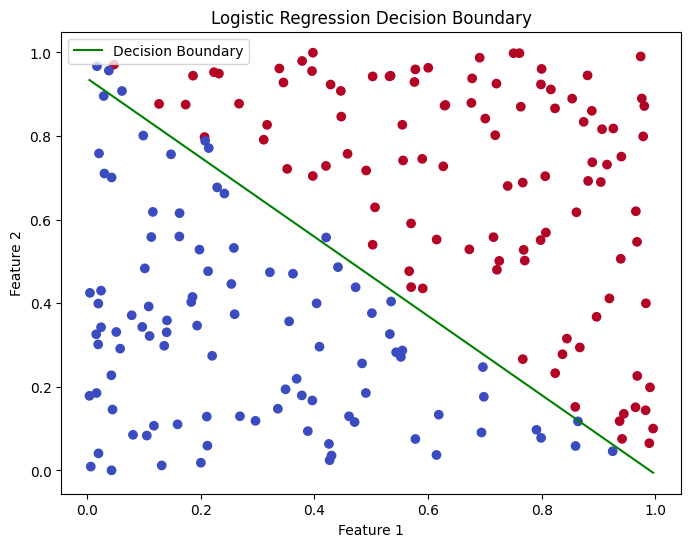

In [4]:
# Predictions
def predict(X, theta):
    return sigmoid(X @ theta) >= 0.5

# Evaluate model
y_pred = predict(X_test, theta)
accuracy = np.mean(y_pred == y_test) * 100
print(f'Accuracy: {accuracy:.2f}%')

# Visualize decision boundary
plt.figure(figsize=(8,6))
plt.scatter(X_test[:, 1], X_test[:, 2], c=y_test, cmap='coolwarm')
x_values = [np.min(X_test[:, 1]), np.max(X_test[:, 1])]
y_values = -(theta[0] + np.dot(theta[1], x_values)) / theta[2]
plt.plot(x_values, y_values, label='Decision Boundary', color='green')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.show()